# PRAGMATA 中古価格分析（PS5 / Switch2）

Mercari（メルカリ）日本市場の中古ソフト出品データをもとに、CAPCOM の **PRAGMATA（プラグマタ）** の
PS5 版と Nintendo Switch2 版の中古価格を比較する探索的分析ノートです。

- 対象 `game_id`: `pragmata_ps5`, `pragmata_switch2`
- データ元: `market_listings_clean`（パイプラインで生成済みのクリーン済みテーブル）
- このノートは **読み取り専用** です。スクレイピングやパイプライン実行・データ更新は行いません。

> PRAGMATA は比較的新しいタイトルで、価格はまだ定価付近に集中しています。
> 数値はすべて実行時に DB から読み込んだ最新データに基づきます（過去のスナップショットをハードコードしていません）。

In [1]:
import sqlite3
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_theme(style="whitegrid")

# macOS / Linux に入っている日本語フォントを使い、ラベルが豆腐（□）に
# ならないようにする。無ければそのまま（描画は崩れない）。
for _f in ["Hiragino Sans", "Hiragino Maru Gothic Pro", "YuGothic",
           "Noto Sans CJK JP", "IPAexGothic"]:
    if any(_f == f.name for f in matplotlib.font_manager.fontManager.ttflist):
        plt.rcParams["font.family"] = _f
        break
plt.rcParams["axes.unicode_minus"] = False

## 2. データ読み込み & 品質確認

`market_listings_clean` から PRAGMATA の 2 タイトル分を読み込み、行数・状態・コンディション・価格レンジを
ざっと確認します。

In [2]:
# notebooks/ からでもリポジトリ直下からでも DB を見つけられるように。
def find_db() -> Path:
    for base in (Path.cwd(), Path.cwd().parent):
        p = base / "data" / "mercari.sqlite"
        if p.exists():
            return p
    raise FileNotFoundError(
        "data/mercari.sqlite が見つかりません — 先に scrape / clean ステップを実行してください。"
    )

PLATFORM = {"pragmata_ps5": "PS5", "pragmata_switch2": "Switch2"}

conn = sqlite3.connect(find_db())
df_all = pd.read_sql_query(
    """
    SELECT game_id, listing_id, price_jpy, status_final, condition_raw,
           platform_final, title_raw, scraped_at, created_at, days_since_release
    FROM market_listings_clean
    WHERE game_id IN ('pragmata_ps5', 'pragmata_switch2')
    """,
    conn,
)
conn.close()

# 表示用のプラットフォーム列（game_id 由来＝データセットの区分）
df_all["platform"] = df_all["game_id"].map(PLATFORM)
print("df_all.shape:", df_all.shape)
df_all.head()

df_all.shape: (1017, 11)


,game_id,listing_id,price_jpy,status_final,condition_raw,platform_final,title_raw,scraped_at,created_at,days_since_release,platform
0,pragmata_ps5,m11870632664,5000.0,on_sale,未使用に近い,PS5,PS5 プラグマタ,2026-06-21T14:38:41.408878+00:00,2026-06-22T03:25:54.407305+00:00,58.610201,PS5
1,pragmata_ps5,m74952264365,4950.0,on_sale,未使用に近い,PS5,PS5 PRAGMATA プラグマタ,2026-06-21T14:38:45.666968+00:00,2026-06-22T03:25:54.407541+00:00,58.610251,PS5
2,pragmata_ps5,m92168821815,5000.0,on_sale,未使用に近い,PS5,PS5 PRAGMATA プラグマタ,2026-06-21T14:38:47.800253+00:00,2026-06-22T03:25:54.407564+00:00,58.610275,PS5
3,pragmata_ps5,m61938166793,5000.0,on_sale,目立った傷や汚れなし,PS5,PS5 PRAGMATA プラグマタ,2026-06-21T14:38:52.056482+00:00,2026-06-22T03:25:54.407579+00:00,58.610325,PS5
4,pragmata_ps5,m54710736635,5000.0,on_sale,目立った傷や汚れなし,PS5,PS5 プラグマタ,2026-06-21T14:38:54.182446+00:00,2026-06-22T03:25:54.407592+00:00,58.610349,PS5


### データ品質メモ：グッズ（非ゲーム）行の混入について

PRAGMATA のクリーンテーブルには、**ゲームソフト本体ではないグッズ系の出品** が少量混入している可能性があります。
具体的には フィギュア / アクリルスタンド / クリアファイル / ポストカード / マグネット などで、
これらはタイトルに「PRAGMATA・プラグマタ」を含むため検索に引っかかり、
**現状の除外キーワード設定がグッズ系をすべてはカバーできていない** ために残っています。

このノートは **データを書き換えません**。代わりに、外れ値セクション（第6章）で実際に残っている例を確認し、
中央値など外れ値に強い指標を中心に相場を読みます。

（補足）検索キーワードが PS5 / Switch2 で共通のため、`platform_final` で見ると一部に反対プラットフォーム推定の
行も含まれます。規模は下のクロス集計で確認できますが、PRAGMATA では少数のため、
本ノートの比較は `game_id` 由来の `platform` 区分で行います。

In [3]:
print("=== game_id 別 行数 ===")
print(df_all["game_id"].value_counts(), "\n")

print("=== platform（データセット区分） × platform_final（推定） クロス集計 ===")
print(pd.crosstab(df_all["platform"], df_all["platform_final"]), "\n")

print("=== status_final 別 件数 ===")
print(df_all.groupby("platform")["status_final"].value_counts(), "\n")

print("=== condition_raw 別 件数（上位8） ===")
print(df_all["condition_raw"].value_counts().head(8), "\n")

print("=== price_jpy の min / median / max（platform別） ===")
print(df_all.groupby("platform")["price_jpy"].agg(["count", "min", "median", "mean", "max"]).round(0))

=== game_id 別 行数 ===
game_id
pragmata_switch2    515
pragmata_ps5        502
Name: count, dtype: int64 

=== platform（データセット区分） × platform_final（推定） クロス集計 ===
platform_final  PS5  Switch 2  ambiguous  unknown
platform                                         
PS5             452         9          0       41
Switch2           2       448          1       64 

=== status_final 別 件数 ===
platform  status_final
PS5       sold_out        407
          on_sale          92
          trading           3
Switch2   sold_out        433
          on_sale          80
          trading           2
Name: count, dtype: int64 

=== condition_raw 別 件数（上位8） ===
condition_raw
目立った傷や汚れなし    466
未使用に近い        426
新品、未使用        122
やや傷や汚れあり        3
Name: count, dtype: int64 

=== price_jpy の min / median / max（platform別） ===
          count    min  median    mean      max
platform                                       
PS5         502  440.0  5500.0  5531.0  19999.0
Switch2     515  440.0  6299.0  6316.0  19

In [4]:
# プラットフォーム別データ（game_id 区分）
df_ps5 = df_all[df_all.game_id == "pragmata_ps5"].copy()
df_sw2 = df_all[df_all.game_id == "pragmata_switch2"].copy()
print(f"PS5版   : {len(df_ps5)} 行")
print(f"Switch2版: {len(df_sw2)} 行")

def price_hist(d, title, color="steelblue"):
    """価格ヒストグラム（500円刻み）。極端な外れ値で潰れないよう98パーセンタイル以下を表示。"""
    hi = int(np.ceil(d["price_jpy"].quantile(0.98) / 500) * 500)
    sub = d[d["price_jpy"] <= hi]
    bins = np.arange(0, hi + 500, 500)
    fig, ax = plt.subplots(figsize=(9, 4))
    sns.histplot(sub["price_jpy"], bins=bins, color=color, ax=ax)
    ax.set_title(title)
    ax.set_xlabel("価格（円, 500円刻み・98パーセンタイル以下を表示）")
    ax.set_ylabel("件数")
    plt.show()

PS5版   : 502 行
Switch2版: 515 行


## 3. PS5版の価格分布

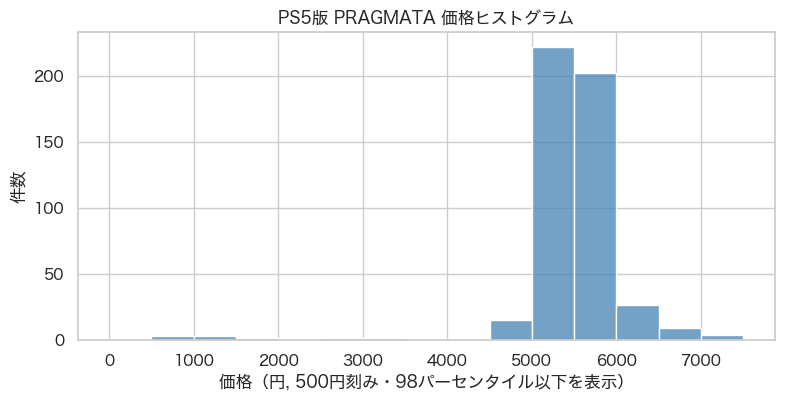

In [5]:
price_hist(df_ps5, "PS5版 PRAGMATA 価格ヒストグラム", color="steelblue")

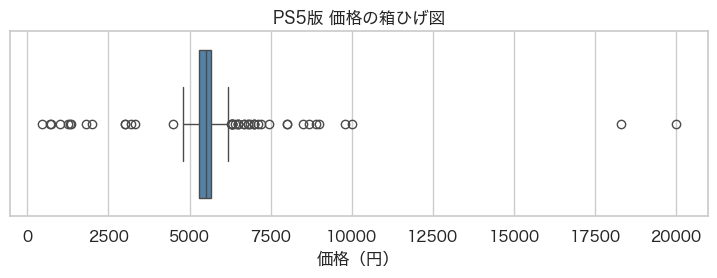

In [6]:
fig, ax = plt.subplots(figsize=(9, 2.4))
sns.boxplot(x=df_ps5["price_jpy"], color="steelblue", ax=ax)
ax.set_title("PS5版 価格の箱ひげ図")
ax.set_xlabel("価格（円）")
plt.show()

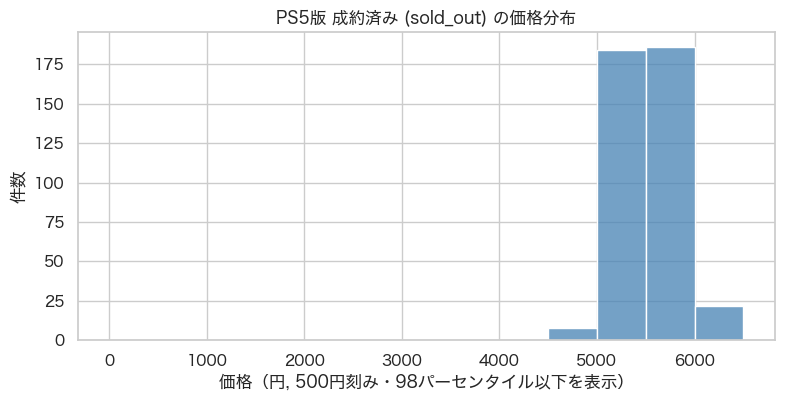

In [7]:
price_hist(df_ps5[df_ps5.status_final == "sold_out"], "PS5版 成約済み (sold_out) の価格分布", color="steelblue")

PS5 版は中央値が **5,500円前後** に強く集中しています。発売から日が浅い新作タイトルらしく、
四分位範囲（IQR）は狭く、定価付近にほぼ張り付いた相場です。成約済み（sold_out）だけ見ても
中心はほぼ同じで、「ほぼ定価で売買が成立している」状態と読めます。

## 4. Switch2版の価格分布

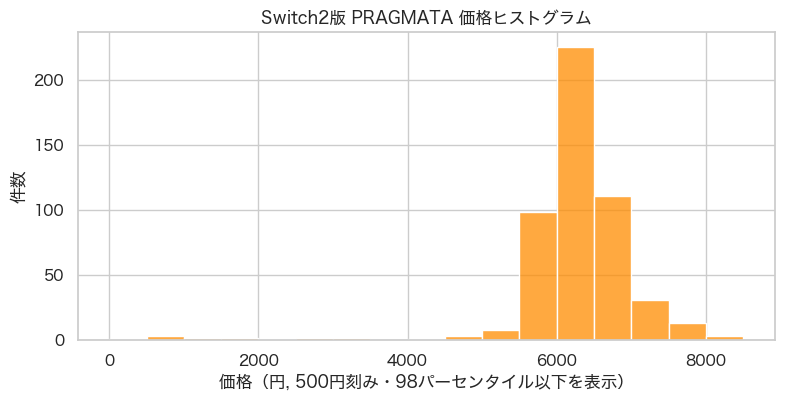

In [8]:
price_hist(df_sw2, "Switch2版 PRAGMATA 価格ヒストグラム", color="darkorange")

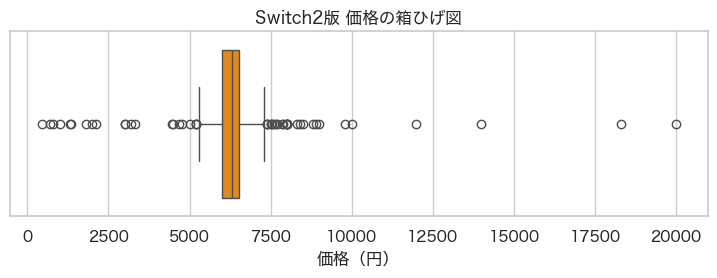

In [9]:
fig, ax = plt.subplots(figsize=(9, 2.4))
sns.boxplot(x=df_sw2["price_jpy"], color="darkorange", ax=ax)
ax.set_title("Switch2版 価格の箱ひげ図")
ax.set_xlabel("価格（円）")
plt.show()

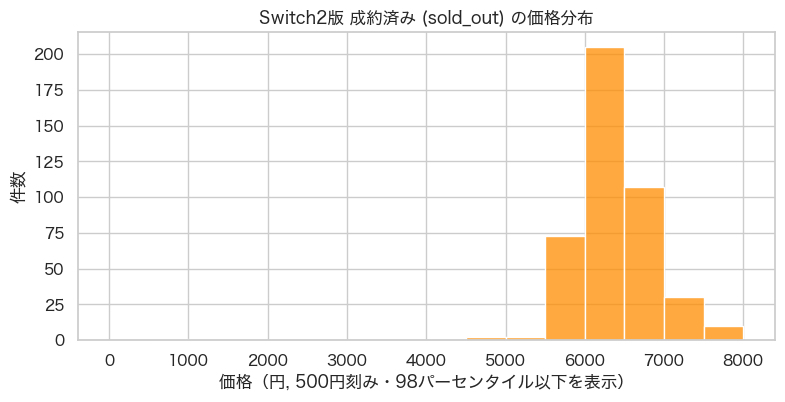

In [10]:
price_hist(df_sw2[df_sw2.status_final == "sold_out"], "Switch2版 成約済み (sold_out) の価格分布", color="darkorange")

Switch2 版は中央値が **6,300円前後** と、PS5 版より一段高い位置に山があります。
こちらも分布はタイトで、定価付近に集中。新プラットフォーム向けで供給がまだ少ないことが、
やや高めの相場につながっていると考えられます。

## 5. PS5 vs Switch2 比較

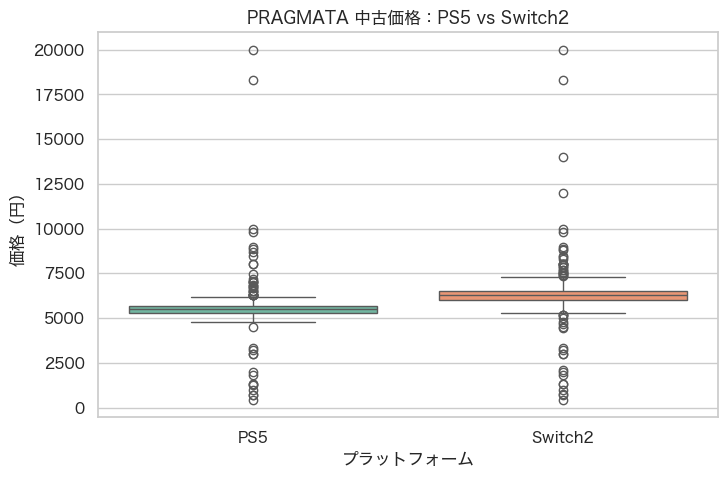

In [11]:
df_cmp = pd.concat([df_ps5, df_sw2], ignore_index=True)

fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=df_cmp, x="platform", y="price_jpy", hue="platform",
            order=["PS5", "Switch2"], palette="Set2", legend=False, ax=ax)
ax.set_title("PRAGMATA 中古価格：PS5 vs Switch2")
ax.set_xlabel("プラットフォーム")
ax.set_ylabel("価格（円）")
plt.show()

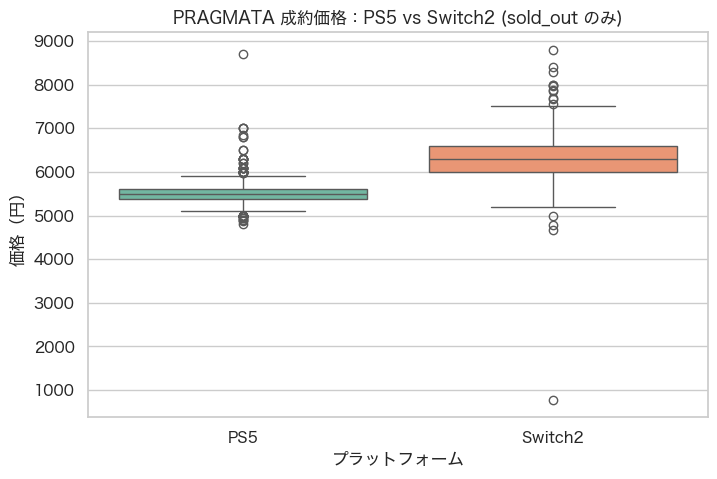

In [12]:
sold = df_cmp[df_cmp.status_final == "sold_out"]
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=sold, x="platform", y="price_jpy", hue="platform",
            order=["PS5", "Switch2"], palette="Set2", legend=False, ax=ax)
ax.set_title("PRAGMATA 成約価格：PS5 vs Switch2 (sold_out のみ)")
ax.set_xlabel("プラットフォーム")
ax.set_ylabel("価格（円）")
plt.show()

In [13]:
def summarize(d):
    return pd.Series({
        "件数": len(d),
        "成約率": round((d["status_final"] == "sold_out").mean(), 3),
        "価格中央値": d["price_jpy"].median(),
        "平均価格": round(d["price_jpy"].mean()),
        "第1四分位": d["price_jpy"].quantile(0.25),
        "第3四分位": d["price_jpy"].quantile(0.75),
    })

summary = (df_cmp.groupby("platform", group_keys=False)[["price_jpy", "status_final"]]
           .apply(summarize)
           .reindex(["PS5", "Switch2"]))
summary.index.name = "プラットフォーム"

gap = df_sw2["price_jpy"].median() - df_ps5["price_jpy"].median()
print(f"中央値の差（Switch2 − PS5）: {gap:,.0f} 円")
summary

中央値の差（Switch2 − PS5）: 799 円


,件数,成約率,価格中央値,平均価格,第1四分位,第3四分位
プラットフォーム,,,,,,
PS5,502.0,0.811,5500.0,5531.0,5300.0,5664.5
Switch2,515.0,0.841,6299.0,6316.0,6000.0,6525.0


- **中央値が高いのは Switch2 版**：PS5 ≒ 5,500円 / Switch2 ≒ 6,300円 で、**約 800円** の差があります。
- **成約（売り切れ）が多いのは Switch2 版**：成約率は PS5 が約 81%、Switch2 が約 84% と、Switch2 がやや高め。
- **分布の重なり**：両者とも定価付近に強く集中しており、価格レンジは大きく重なります。
  ただし山の位置が約 800円ずれているため、**「同じ形のまま Switch2 が少し上にシフト」** したイメージです。

## 6. 外れ値とデータ上の注意点

In [14]:
cols = ["game_id", "platform_final", "price_jpy", "status_final", "title_raw"]
print("=== 価格 上位10件 ===")
display(df_all.nlargest(10, "price_jpy")[cols])
print("=== 価格 下位10件 ===")
display(df_all.nsmallest(10, "price_jpy")[cols])

=== 価格 上位10件 ===


,game_id,platform_final,price_jpy,status_final,title_raw
411,pragmata_ps5,unknown,19999.0,on_sale,CAPCOM PRAGMATA 香港販促用ディスプレイスタンド パネルA4サイズ
810,pragmata_switch2,unknown,19999.0,on_sale,CAPCOM PRAGMATA 香港販促用ディスプレイスタンド パネルA4サイズ
43,pragmata_ps5,unknown,18300.0,on_sale,Switch２ CAPCOM名作アクション バイオハザードとプラグマタ
519,pragmata_switch2,unknown,18300.0,on_sale,Switch２ CAPCOM名作アクション バイオハザードとプラグマタ
815,pragmata_switch2,Switch 2,14000.0,on_sale,PRAGMATA Nintendo Switch2 早期購入特典付きアマゾン特典
587,pragmata_switch2,Switch 2,12000.0,on_sale,真・三國無双 ORIGINS プラグマタNintendo Switch2
383,pragmata_ps5,unknown,10000.0,on_sale,プラグマタ PRAGMATA アクリルブロック
796,pragmata_switch2,unknown,10000.0,on_sale,プラグマタ PRAGMATA アクリルブロック
127,pragmata_ps5,unknown,9800.0,on_sale,PRAGMATA アクリルスタンド ディアナちゃんのアクスタ
553,pragmata_switch2,unknown,9800.0,on_sale,PRAGMATA アクリルスタンド ディアナちゃんのアクスタ


=== 価格 下位10件 ===


,game_id,platform_final,price_jpy,status_final,title_raw
6,pragmata_ps5,unknown,440.0,on_sale,プラグマタ
503,pragmata_switch2,unknown,440.0,on_sale,プラグマタ
381,pragmata_ps5,unknown,699.0,on_sale,カプコンストア PRAGMATA プラグマタ 特典 父の日 ポストカード 4枚
795,pragmata_switch2,unknown,699.0,on_sale,カプコンストア PRAGMATA プラグマタ 特典 父の日 ポストカード 4枚
161,pragmata_ps5,PS5,729.0,on_sale,PS5版 プラグマタ PRAGMATA 早期購入特典
936,pragmata_switch2,ambiguous,777.0,sold_out,プラグマタ 応募券 懸賞 Switch2 PS5 ゲーム Vジャンプ
124,pragmata_ps5,unknown,999.0,on_sale,PRAGMATA プラグマタ ディアナ&ヒュー 両面しおり
548,pragmata_switch2,unknown,999.0,on_sale,PRAGMATA プラグマタ ディアナ&ヒュー 両面しおり
125,pragmata_ps5,PS5,1250.0,on_sale,プラグマタ PRAGMATA PS5 ステッカー 3枚入り
75,pragmata_ps5,unknown,1299.0,on_sale,非売品 プラグマタ ダミージャケット PRAGMATA 合計4枚 詳細は⇒


上位・下位の外れ値には、ゲームソフト本体ではない行が混じっています。例として、

- 高額側：販促用ディスプレイスタンド、他ソフトとのまとめ売り（例「バイオハザードとプラグマタ」）、早期購入特典付き 等
- 低額側：ポストカードなどグッズ単体、特典のみ・付属品のみと思われる出品 等

第2章で触れたとおり、**除外キーワードがグッズ系をまだ完全にはカバーしていない** ため、
クリーンテーブルには **少数の非ゲーム行（フィギュア／アクリル／クリアファイル／ポストカード等）が残っています**。
相場の中心を見る際は、これら外れ値の影響を受けにくい **中央値・四分位** を主指標にするのが安全です。
（除外キーワードを拡張して候補を作り直せば、これらはさらに減らせます。）

## 7. 簡単な考察とメモ

- **PRAGMATA の中古価格帯の中心**：PS5 ≒ 5,500円、Switch2 ≒ 6,300円。新作のため定価付近に集中。
- **PS5 / Switch2 の差**：Switch2 版が中央値で **約 800円** 高い。供給の少なさ（新プラットフォーム）が効いていると考えられる。
- **成約率の差**：PS5 約 81% / Switch2 約 84%。Switch2 の方がやや売り切れが多い。
- **残る注意点**：グッズ系（フィギュア・アクリル・ポストカード等）の少量混入と、まとめ売り・特典のみ等の外れ値が残存。

**次の分析ステップ**

- 除外キーワードを拡張してグッズ行を削った上で再集計し、相場推定をより正確にする。
- `days_since_release` / `scraped_at` を使った発売直後からの価格推移（値下がりの速さ）。
- コンディション（`condition_raw`）別の価格差、新品 vs 中古の比較。
- `platform_final == 'unknown'` 行の素性確認（どちらの版か判定できるか）。